In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
# Load dataset
df = pd.read_csv("../data/Raw/Superstore.csv", encoding='latin1')

In [97]:
# -------------------------------
# 1. Data Cleaning
# -------------------------------

df.dtypes #converted into datetime

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [98]:

print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows: 0


In [99]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.dtypes #converted into datetime

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [100]:
# -------------------------------
# 3. FUNCTION: Detect Outliers (IQR)
# -------------------------------
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column} outliers count:", len(outliers))
    print(f"{column} lower bound: {lower_bound}, upper bound: {upper_bound}")

    return outliers, lower_bound, upper_bound

In [101]:
# -------------------------------
# 4. FUNCTION: Handle Outliers (Capping)
# -------------------------------
def cap_outliers(df, column, lower_bound, upper_bound):
    df[column] = df[column].clip(lower_bound, upper_bound)
    return df

In [102]:
# -------------------------------
# 5. OUTLIER ANALYSIS (BEFORE)
# -------------------------------

# Profit (detect only)
profit_outliers, lb_p, ub_p = detect_outliers(df, 'Profit')

# Sales (detect + will handle)
sales_outliers, lb_s, ub_s = detect_outliers(df, 'Sales')

# Quantity (detect only)
quantity_outliers, lb_q, ub_q = detect_outliers(df, 'Quantity')

# Quantity (detect only)
discount_outliers, lb_q, ub_q = detect_outliers(df, 'Discount')

Profit outliers count: 1881
Profit lower bound: -39.724125, upper bound: 70.816875
Sales outliers count: 1167
Sales lower bound: -271.71000000000004, upper bound: 498.93
Quantity outliers count: 170
Quantity lower bound: -2.5, upper bound: 9.5
Discount outliers count: 856
Discount lower bound: -0.30000000000000004, upper bound: 0.5


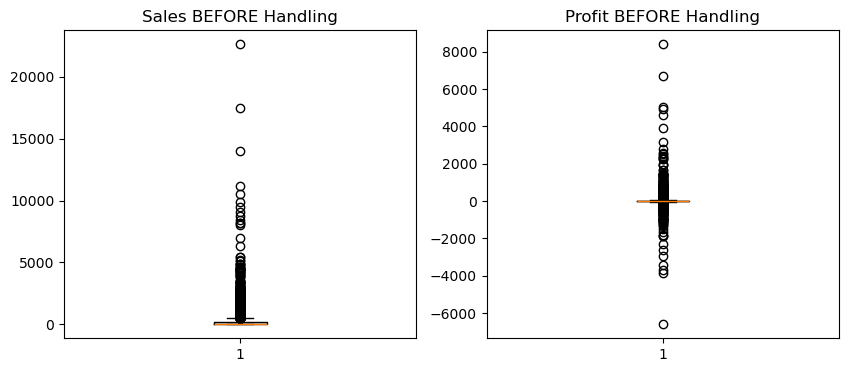

In [103]:
# -------------------------------
# 6. VISUALIZE BEFORE HANDLING
# -------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df['Sales'])
plt.title("Sales BEFORE Handling")

plt.subplot(1,2,2)
plt.boxplot(df['Profit'])
plt.title("Profit BEFORE Handling")

plt.show()


In [104]:
# -------------------------------
# 7. HANDLE OUTLIERS (ONLY SALES)
# -------------------------------
df = cap_outliers(df, 'Sales', lb_s, ub_s)

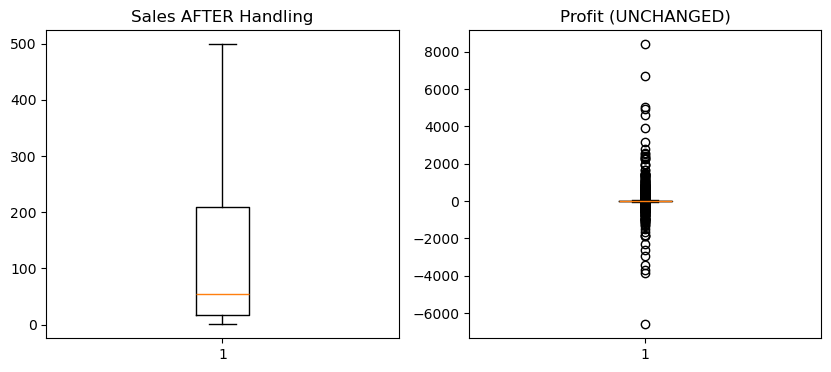

In [105]:
# -------------------------------
# 8. VISUALIZE AFTER HANDLING
# -------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df['Sales'])
plt.title("Sales AFTER Handling")

plt.subplot(1,2,2)
plt.boxplot(df['Profit'])
plt.title("Profit (UNCHANGED)")

plt.show()

In [106]:
# -------------------------------
# 9. LOSS ANALYSIS
# -------------------------------
loss_df = df[df['Profit'] < 0]

print("Total Loss:", loss_df['Profit'].sum())

print("\nCategory Loss:\n", loss_df.groupby('Category')['Profit'].sum())
print("\nSub-Category Loss:\n", loss_df.groupby('Sub-Category')['Profit'].sum())
print("\nRegion Loss:\n", loss_df.groupby('Region')['Profit'].sum())


Total Loss: -156131.2857

Category Loss:
 Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64

Sub-Category Loss:
 Sub-Category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: Profit, dtype: float64

Region Loss:
 Region
Central   -56314.8850
East      -49590.6075
South     -27504.8323
West      -22720.9609
Name: Profit, dtype: float64


In [107]:
# -------------------------------
# 10. Discount Impact (FIXED)
# -------------------------------
loss_df['Discount_Bin'] = pd.cut(
    loss_df['Discount'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

print("\nDiscount Impact:\n",
      loss_df.groupby('Discount_Bin')['Profit'].sum())


Discount Impact:
 Discount_Bin
(0.0, 0.2]   -17616.0428
(0.2, 0.4]   -38956.6524
(0.4, 0.6]   -28944.1944
(0.6, 0.8]   -70614.3961
Name: Profit, dtype: float64


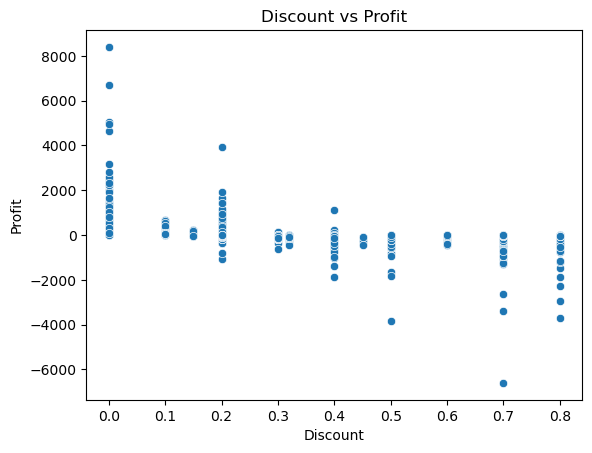

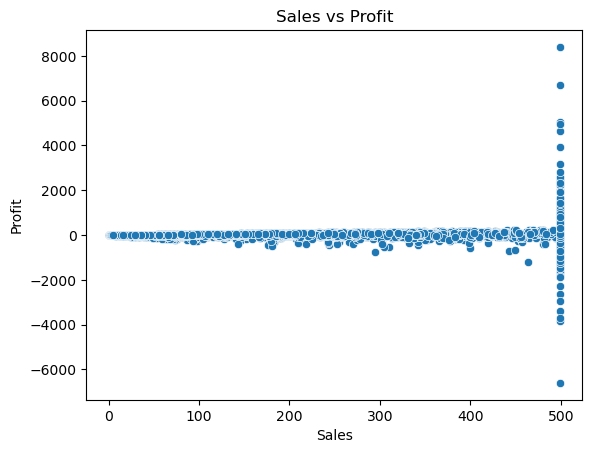

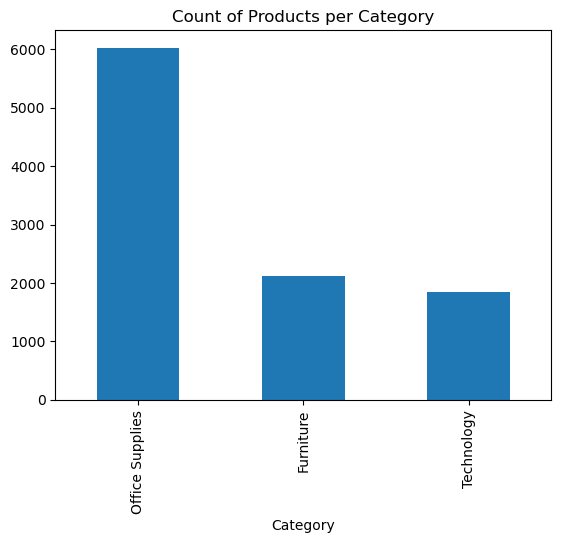

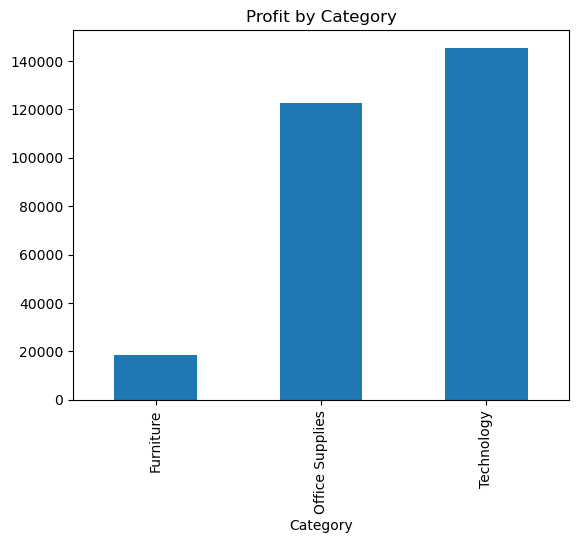

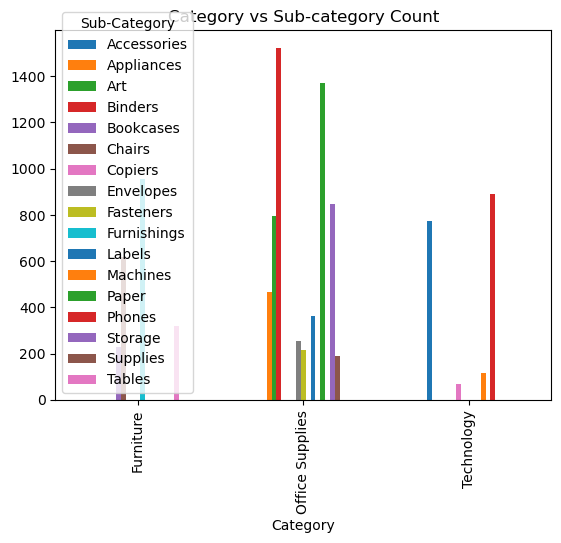

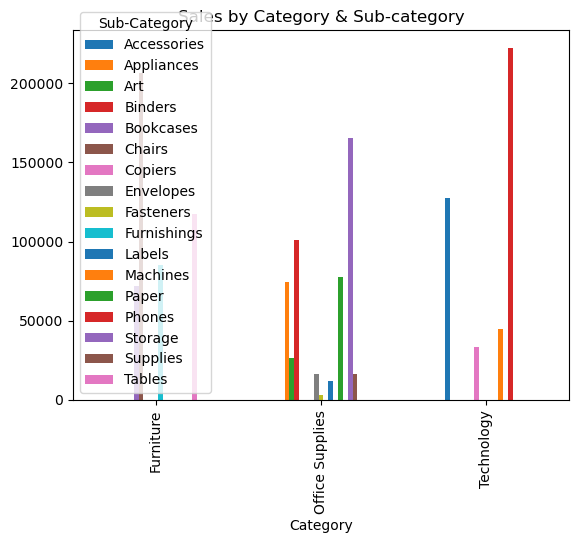

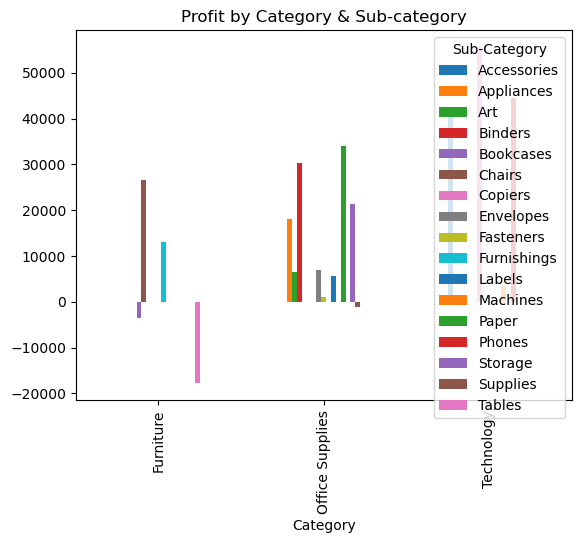

In [108]:
# -------------------------------
# 11. VISUALIZATIONS
# -------------------------------

# Discount vs Profit
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

# Sales vs Profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

# Category Count
df['Category'].value_counts().plot(kind='bar')
plt.title("Count of Products per Category")
plt.show()

# Profit by Category
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

# Category vs Sub-category
count_data = df.groupby(['Category', 'Sub-Category']).size().unstack()
count_data.plot(kind='bar')
plt.title("Category vs Sub-category Count")
plt.show()

# Sales by Category
sales_data = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().unstack()
sales_data.plot(kind='bar')
plt.title("Sales by Category & Sub-category")
plt.show()

# Profit Table
profit_table = df.groupby(['Category', 'Sub-Category'])['Profit'].sum().unstack()
profit_table.plot(kind='bar')
plt.title("Profit by Category & Sub-category")
plt.show()

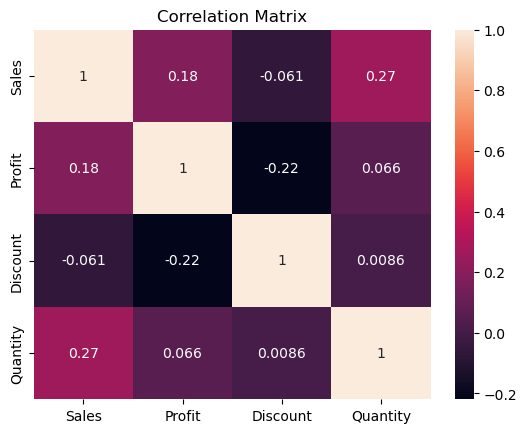

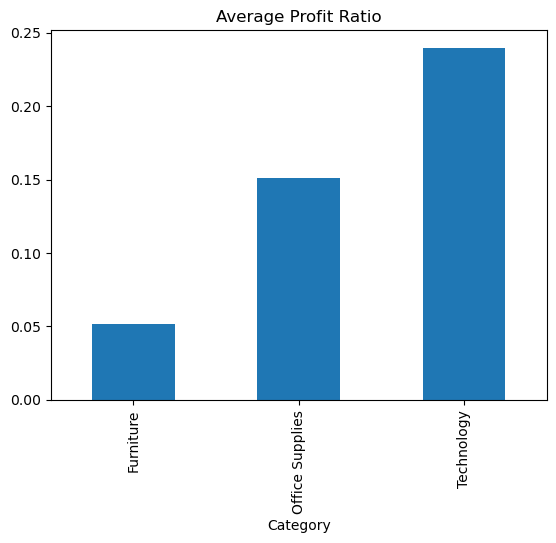

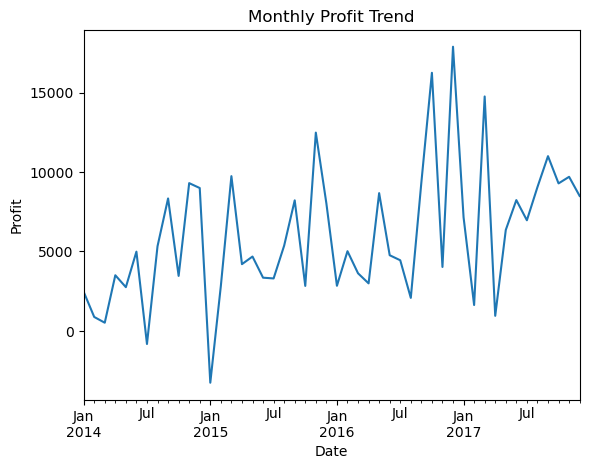

In [109]:
# -------------------------------
# 12. ADVANCED ANALYSIS
# -------------------------------

# Correlation
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Profit Ratio
df['Profit Ratio'] = df['Profit'] / df['Sales']

df.groupby('Category')['Profit Ratio'].mean().plot(kind='bar')
plt.title("Average Profit Ratio")
plt.show()

# Monthly Trend (FIXED)
monthly = df.resample('ME', on='Order Date')['Profit'].sum()

monthly.plot()
plt.title("Monthly Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.show()

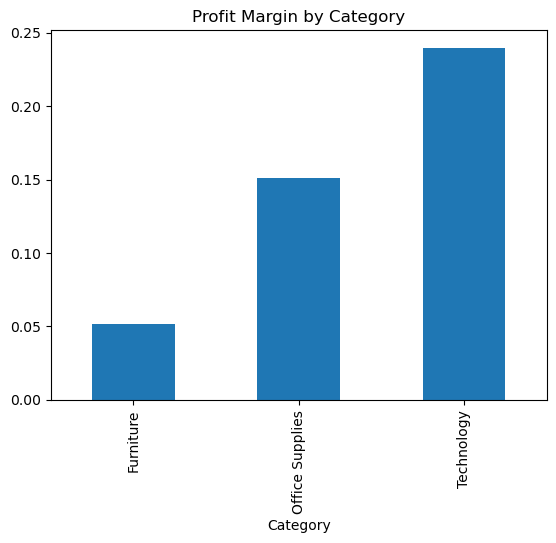

In [110]:
# -------------------------------
# 11. KPI (PROFIT MARGIN)
# -------------------------------
df['Profit Margin'] = df['Profit'] / df['Sales']

df.groupby('Category')['Profit Margin'].mean().plot(kind='bar')
plt.title("Profit Margin by Category")
plt.show()

In [111]:
# -------------------------------
# 12. TOP & WORST PRODUCTS
# -------------------------------
top_products = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
worst_products = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)

print("\nTop Products:\n", top_products)
print("\nWorst Products:\n", worst_products)



Top Products:
 Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Name: Profit, dtype: float64

Worst Products:
 Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64


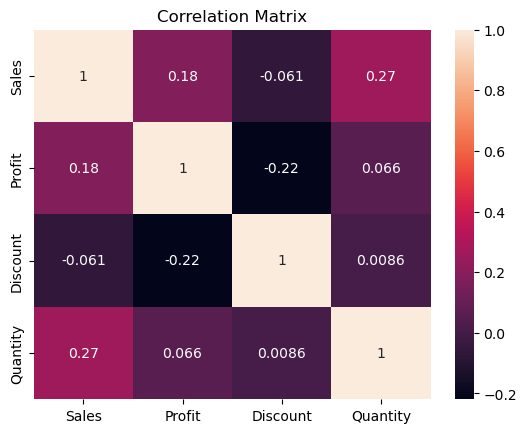

In [112]:
# -------------------------------
# 13. CORRELATION
# -------------------------------
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

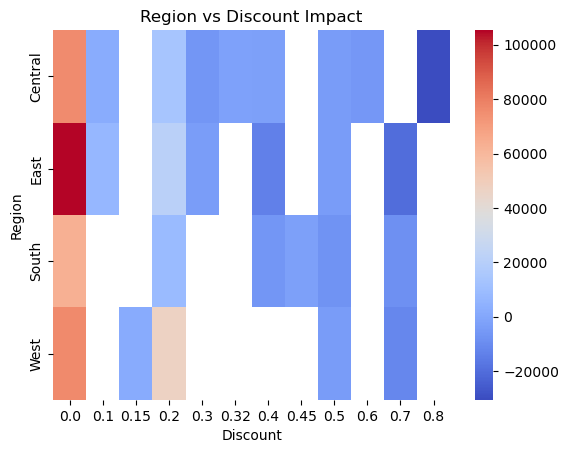

In [113]:
# -------------------------------
# 14. REGION + DISCOUNT ANALYSIS
# -------------------------------
pivot = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Discount',
    aggfunc='sum'
)

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Region vs Discount Impact")
plt.show()

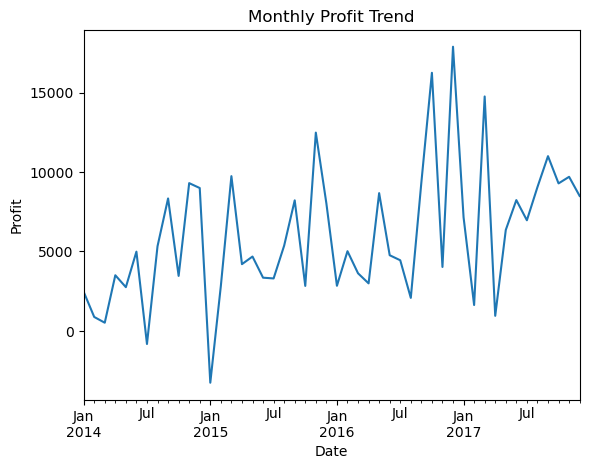

In [114]:
# -------------------------------
# 15. TIME ANALYSIS
# -------------------------------
monthly = df.resample('ME', on='Order Date')['Profit'].sum()

monthly.plot()
plt.title("Monthly Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.show()

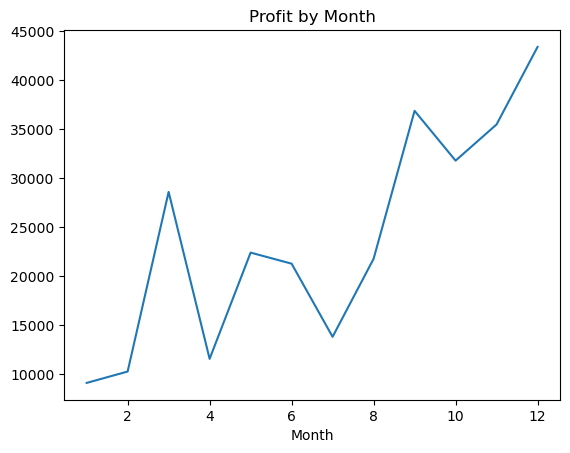

In [115]:
# Month-wise analysis
df['Month'] = df['Order Date'].dt.month

df.groupby('Month')['Profit'].sum().plot()
plt.title("Profit by Month")
plt.show()

In [118]:
worst_products = df.groupby('Sub-Category')['Profit'].sum()
worst_products = worst_products[worst_products < 0].sort_values()
print(worst_products)

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64
